In [ ]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/fish01.csv")
df.head()

In [ ]:
# 컬럼명을 한글로 변경하기
df.rename(columns=dict(zip(df.columns.to_list(),["종류", "무게", "길이", "대각길이", "높이", "넓이",])), inplace=True)

---

In [2]:
import pandas as pd

In [3]:
df_elec = pd.read_csv("./csv/한국전력거래소_시간별 신재생에너지 거래량_20220331.csv", encoding="euc-kr")
df_elec

,거래일,거래시간,연료전지,석탄가스화복합화력(IGCC),태양광,풍력,수력,해양에너지,바이오에너지,폐기물에너지,신재생 합계
0,2012-01-01,1,49.302058,0.00000,0.000000,208.133273,255.162698,0.000000,25.131512,725.090852,1262.820393
1,2012-01-01,2,49.300968,0.00000,0.000000,180.156435,251.500828,0.000000,24.754470,735.349526,1241.062227
2,2012-01-01,3,49.313352,0.00000,0.000000,165.950089,128.356478,0.000000,24.515154,738.572129,1106.707202
3,2012-01-01,4,49.323810,0.00000,0.000000,160.404442,125.749309,0.000000,24.523868,738.415641,1098.417070
4,2012-01-01,5,49.325796,0.00000,0.000000,164.713942,125.964864,0.000000,24.622286,739.373366,1104.000254
...,...,...,...,...,...,...,...,...,...,...,...
89827,2022-03-31,20,626.871295,259.68656,676.467136,528.124507,339.790932,41.952144,740.347287,0.000000,3213.239861
89828,2022-03-31,21,627.316051,260.44928,344.556767,551.223719,254.924218,0.216720,737.043763,0.000000,2775.730518
89829,2022-03-31,22,626.933235,259.93072,163.807903,489.219116,229.833119,0.007920,718.193095,0.000000,2487.925108
89830,2022-03-31,23,626.805354,259.35000,52.641965,445.178784,189.117448,0.002880,685.939241,0.000000,2259.035672


In [4]:
df_elec[df_elec.columns[2:]] = df_elec[df_elec.columns[2:]].round(2)
df_elec.head(5)

,거래일,거래시간,연료전지,석탄가스화복합화력(IGCC),태양광,풍력,수력,해양에너지,바이오에너지,폐기물에너지,신재생 합계
0,2012-01-01,1,49.30,0.0,0.0,208.13,255.16,0.0,25.13,725.09,1262.82
1,2012-01-01,2,49.30,0.0,0.0,180.16,251.50,0.0,24.75,735.35,1241.06
2,2012-01-01,3,49.31,0.0,0.0,165.95,128.36,0.0,24.52,738.57,1106.71
3,2012-01-01,4,49.32,0.0,0.0,160.40,125.75,0.0,24.52,738.42,1098.42
4,2012-01-01,5,49.33,0.0,0.0,164.71,125.96,0.0,24.62,739.37,1104.00


In [5]:
df_elec['태양광비율'] = (df_elec['태양광'] / df_elec['신재생 합계'] * 100).round(2)
df_elec['거래일'] = pd.to_datetime(df_elec['거래일'])
df_elec['거래일']

0       2012-01-01
1       2012-01-01
2       2012-01-01
3       2012-01-01
4       2012-01-01
           ...    
89827   2022-03-31
89828   2022-03-31
89829   2022-03-31
89830   2022-03-31
89831   2022-03-31
Name: 거래일, Length: 89832, dtype: datetime64[ns]

In [6]:
df_elec.set_index('거래일', inplace=True)
df_elec.index.name

'거래일'

In [7]:
df_resampled = df_elec.resample(rule='ME').mean()
df_resampled

,거래시간,연료전지,석탄가스화복합화력(IGCC),태양광,풍력,수력,해양에너지,바이오에너지,폐기물에너지,신재생 합계,태양광비율
거래일,,,,,,,,,,,
2012-01-31,12.5,46.426720,0.000000,39.674301,128.718293,252.614691,40.695013,53.269422,716.451935,1277.850497,2.857124
2012-02-29,12.5,44.583793,0.000000,50.557601,127.595287,289.760489,46.109583,55.198405,717.399569,1331.204914,3.370675
2012-03-31,12.5,43.783441,0.000000,58.869973,131.245148,343.594610,55.175444,45.161344,594.711196,1272.541035,4.025013
2012-04-30,12.5,42.611611,0.000000,71.339847,126.108889,593.129125,54.695264,33.523069,689.301014,1610.708861,4.140722
2012-05-31,12.5,42.422648,0.000000,75.579315,58.864677,461.477675,56.470403,56.233212,612.406667,1363.454368,4.819126
...,...,...,...,...,...,...,...,...,...,...,...
2021-11-30,12.5,572.375097,234.616292,617.575042,475.120639,241.622319,50.351986,657.339500,0.000000,2849.001069,17.651250
2021-12-31,12.5,600.709570,237.955712,563.211492,581.034597,238.480941,50.547446,829.529153,0.000000,3101.469005,14.941263
2022-01-31,12.5,591.297634,253.527608,727.148199,463.147540,251.533858,52.152917,763.978199,0.000000,3102.786317,18.189261


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
import matplotlib.ticker as ticker

rc('font', family='Gulim')
f, ax = plt.subplots(figsize=(20,5))
sns.set_color_codes("pastel")
p2 = sns.barplot(data=df_resampled, x='거래일', y='신재생 합계', color='g')
sns.set_color_codes("muted")
p1 = sns.barplot(data=df_resampled, x='거래일', y='수력', color='b')
ax.xaxis.set_major_locator(ticker.IndexLocator(base=3, offset=0))
plt.xticks(rotation=60, ha='center')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
from matplotlib.font_manager import FontProperties

rc('font', family='Malgun Gothic')
font_path = "C:/Windows/Fonts/malgun.ttf"  # Use /Library/Fonts/AppleGothic.ttf on macOS
korean_font = FontProperties(fname=font_path)

sns.set_theme(style="whitegrid")

_, ax1 = plt.subplots(figsize=(20, 5))

x = np.arange(len(df_resampled))
labels = df_resampled.index

# Total first (largest), then components on top

ax1.bar(x, df_resampled['신재생 합계'], color='g', alpha=0.5, label='신재생 합계')
ax1.bar(x, df_resampled['태양광'], color='orange', alpha=0.7, label='태양광')
ax1.bar(x, df_resampled['수력'], color='b', alpha=0.7, label='수력', bottom=df_resampled['태양광'])

ax1.set_xticks(x[::3])
ax1.set_xticklabels(labels[::3], rotation=60, ha='right')
ax1.legend(prop=korean_font)

# plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
import matplotlib.ticker as ticker
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches

sns.set_theme(style="whitegrid")
plt.rcParams['legend.fontsize'] = 10
rc('font', family='Malgun Gothic')
sns.set_theme(style="whitegrid", rc={'font.family': 'Malgun Gothic'})

f, ax = plt.subplots(figsize=(16, 6))

df_plot = df_resampled.reset_index()

sns.barplot(data=df_plot, x='거래일', y='신재생 합계', color='g', alpha=0.5, ax=ax, zorder=1)

sns.barplot(data=df_plot, x='거래일', y='태양광', color='orange', alpha=0.7, ax=ax, zorder=2)

bottom_values = df_plot['태양광'].values
sns.barplot(data=df_plot, x='거래일', y='수력', color='b', alpha=0.7, ax=ax, zorder=3, bottom=bottom_values)

bottom_values = df_plot['수력'].values + df_plot['태양광'].values
sns.barplot(data=df_plot, x='거래일', y='풍력', color='r', alpha=0.7, ax=ax, zorder=3, bottom=bottom_values)

bottom_values = df_plot['수력'].values + df_plot['태양광'].values + df_plot['풍력'].values
sns.barplot(data=df_plot, x='거래일', y='해양에너지', color='cyan', alpha=0.7, ax=ax, zorder=3, bottom=bottom_values)

bottom_values = df_plot['수력'].values + df_plot['태양광'].values + df_plot['풍력'].values + df_plot['해양에너지'].values
sns.barplot(data=df_plot, x='거래일', y='바이오에너지', color='violet', alpha=0.7, ax=ax, zorder=3, bottom=bottom_values)

bottom_values = df_plot['수력'].values + df_plot['태양광'].values + df_plot['풍력'].values + df_plot['해양에너지'].values  + df_plot['바이오에너지'].values
sns.barplot(data=df_plot, x='거래일', y='폐기물에너지', color='r', alpha=0.5, ax=ax, zorder=3, bottom=bottom_values)

bottom_values = df_plot['수력'].values + df_plot['태양광'].values + df_plot['풍력'].values + df_plot['해양에너지'].values  + df_plot['바이오에너지'].values + df_plot['폐기물에너지'].values
sns.barplot(data=df_plot, x='거래일', y='연료전지', color='b', alpha=0.5, ax=ax, zorder=3, bottom=bottom_values)

bottom_values = df_plot['수력'].values + df_plot['태양광'].values + df_plot['풍력'].values + df_plot['해양에너지'].values  + df_plot['바이오에너지'].values + df_plot['폐기물에너지'].values + df_plot['연료전지'].values
sns.barplot(data=df_plot, x='거래일', y='석탄가스화복합화력(IGCC)', color='yellow', alpha=0.4, ax=ax, zorder=3, bottom=bottom_values)

ax.legend_ = None

# Legend AFTER plots
handles = [
    mpatches.Patch(color='g', alpha=0.5),
    mpatches.Patch(color='orange', alpha=0.7),
    mpatches.Patch(color='b', alpha=0.7),
    mpatches.Patch(color='red', alpha=0.7),
]

legend = ax.legend(handles=handles, labels=['신재생 합계', '태양광', '수력', '풍력'], prop=korean_font)

# Force font on each legend text
for text in legend.get_texts():
    text.set_fontproperties(korean_font)

ax.xaxis.set_major_locator(ticker.IndexLocator(base=3, offset=0))
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
import matplotlib.ticker as ticker
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
import numpy as np

f, ax = plt.subplots(figsize=(16, 6))

df_plot = df_resampled.reset_index()

# Define stack order and colors
stack_cols = ['태양광', '수력', '풍력', '해양에너지', '바이오에너지', '폐기물에너지', '연료전지', '석탄가스화복합화력(IGCC)']
colors     = ['orange',  'b',   'r',   'cyan',      'violet',      'r',          'b',      'yellow']
alphas     = [0.7,       0.7,   0.7,   0.7,         0.7,           0.5,          0.5,      0.4]

# Background total bar
sns.barplot(data=df_plot, x='거래일', y='신재생 합계', color='g', alpha=0.5, ax=ax, zorder=1)

# Cumulative bottom using cumsum
bottoms = np.zeros(len(df_plot))
for col, color, alpha in zip(stack_cols, colors, alphas):
    sns.barplot(data=df_plot, x='거래일', y=col, color=color, alpha=alpha, ax=ax, zorder=2, bottom=bottoms)
    bottoms += df_plot[col].values

handles = [mpatches.Patch(color='g', alpha=0.5)] + \
          [mpatches.Patch(color=c, alpha=a) for c, a in zip(colors, alphas)]
labels  = ['신재생 합계'] + stack_cols

legend = ax.legend(handles=handles, labels=labels)

ax.xaxis.set_major_locator(ticker.IndexLocator(base=3, offset=0))
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

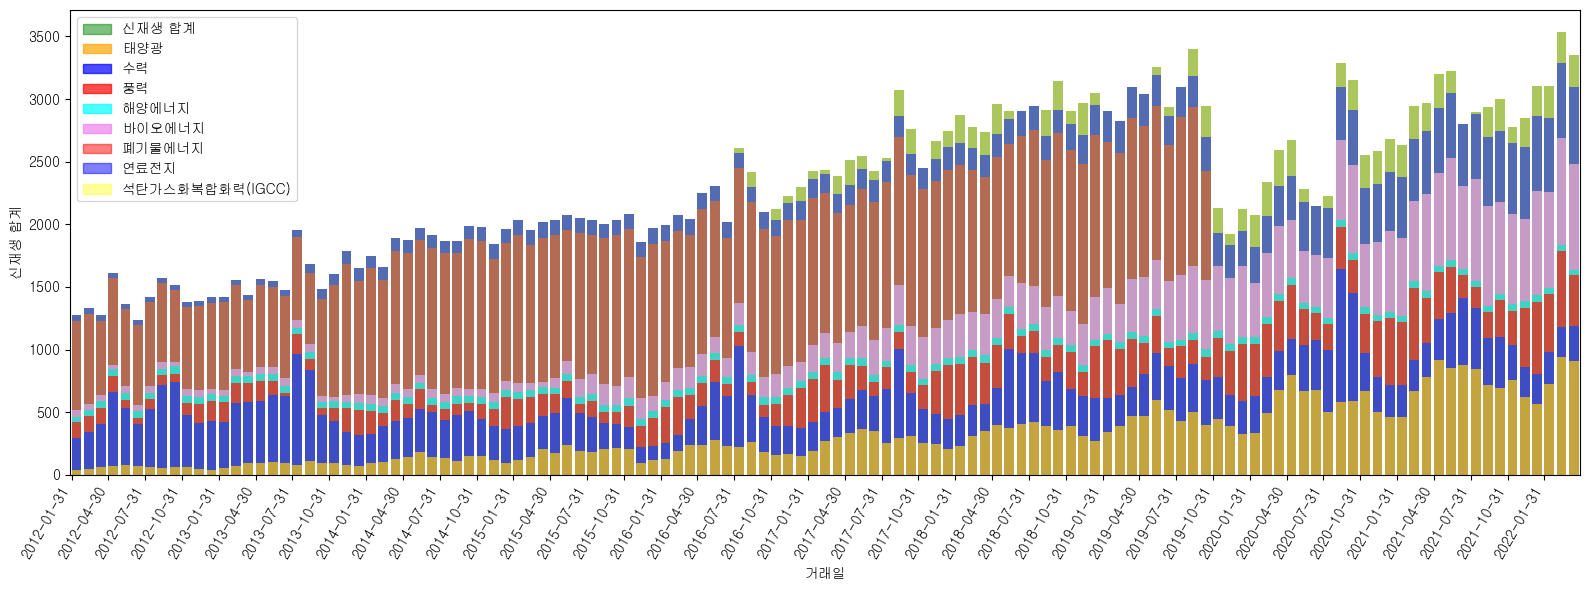

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
import matplotlib.ticker as ticker
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
import numpy as np
import seaborn_cjk

seaborn_cjk.patch("Gulim")

plt.rcParams['legend.fontsize'] = 10

f, ax = plt.subplots(figsize=(16, 6))

df_plot = df_resampled.reset_index()

# Define stack order and colors
stack_cols = ['태양광', '수력', '풍력', '해양에너지', '바이오에너지', '폐기물에너지', '연료전지', '석탄가스화복합화력(IGCC)']
colors     = ['orange',  'b',   'r',   'cyan',      'violet',      'r',          'b',      'yellow']
alphas     = [0.7,       0.7,   0.7,   0.7,         0.7,           0.5,          0.5,      0.4]

# Background total bar
sns.barplot(data=df_plot, x='거래일', y='신재생 합계', color='g', alpha=0.5, ax=ax, zorder=1)

# Cumulative bottom using cumsum
bottoms = np.zeros(len(df_plot))
for col, color, alpha in zip(stack_cols, colors, alphas):
    sns.barplot(data=df_plot, x='거래일', y=col, color=color, alpha=alpha, ax=ax, zorder=2, bottom=bottoms)
    bottoms += df_plot[col].values

handles = [mpatches.Patch(color='g', alpha=0.5)] + \
          [mpatches.Patch(color=c, alpha=a) for c, a in zip(colors, alphas)]
labels  = ['신재생 합계'] + stack_cols

legend = ax.legend(handles=handles, labels=labels)

ax.xaxis.set_major_locator(ticker.IndexLocator(base=3, offset=0))
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()